## Investment Simulation for the Rational Agent, GP, and Learning Under Experience

This notebook contains analysis and simulation of the rational agent, the gaussian
process, and the experience-only agent. All code was built from custom modules that
solve the rational investment agents problem, custom GP model that simulates the
firms GP prior over the action space, and finally the firm as an imperfect problem
solver using ONLY experience.

In [1]:
import sys
sys.path.append("../")
from src.simulation.firm import * # custom firm code
from src.simulation.gaussian_process import * # custom GP code

import matplotlib.pyplot as plt


#### The Rational Agent

The following builds and solves the rational agents problem. We first set up the investment
environment. Here we consider the interest rate (`R`) to be 2%, the depreciation rate of capital
stock (`DELTA`) to be 5%. The productivity shock to be log normal distribution with `SIGMA_EPS=0.05`.
There is a quadratic capital adjustment cost with a factor `KAPPA=0.5`. Capital adjustment
makes for nice numerical stability, a borrowing constraint would also help and will
be added in the near future.

Under these parameters the steady state capital will be close to 10.

In [7]:
p = InvestmentParameters(KAPPA=0.5, SIGMA_EPS=0.05, DELTA=0.05, R=0.02, N_z=5) # parameters for environment
env = InvestmentEnvironment(p, seed=42) # the "world" the agent interacts with
rational_agent = RationalInvestmentAgent(p).fit() # rational benchmark agent
k_ss = rational_agent.fixed_point() # solves for the steady-state capital level

print("Steady State Capital (k_ss):", k_ss)

Steady State Capital (k_ss): 9.949484209768663


##### The Rational Agent Optimal Policy

After solving fitting the rational agent on the environment we have its optimal policy.
We can review this under the $k_t$ versus $k_{t+1}$ phase diagram to see how the agent
chooses next period capital given current state. The policy path represents the stable
manifold of the dynamic system. Given the stochastic environment the optimal policy
varies under different productivities.

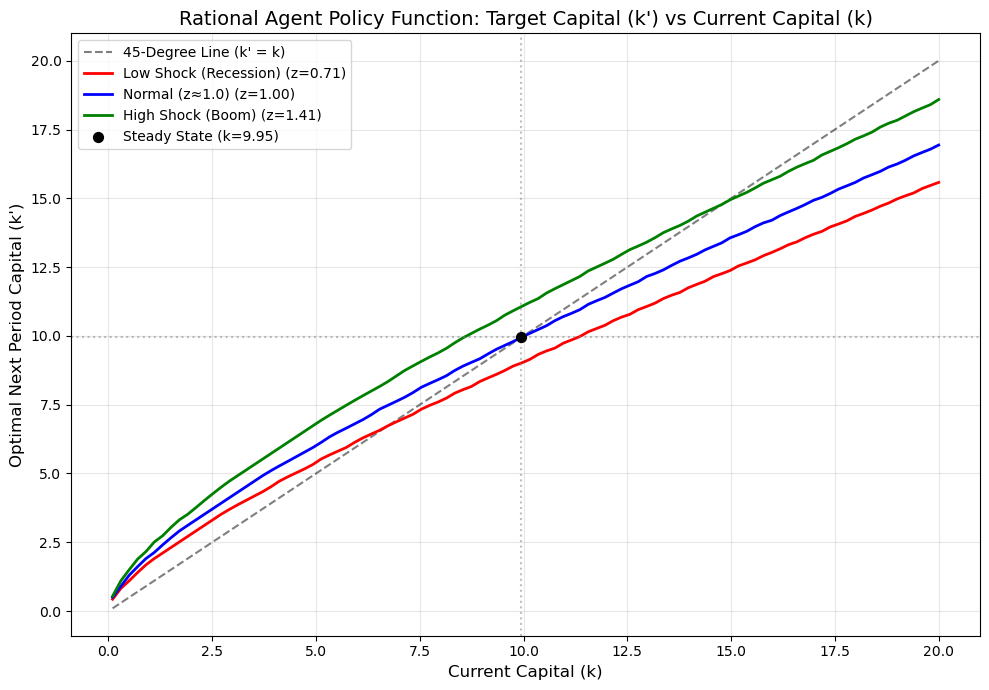

In [17]:
k_grid = rational_agent.k_grid

plt.figure(figsize=(10, 7))

# Plot the 45-degree line (where next period capital equals current capital)
# Intersection = steady state, so this helps visually confirm our solution
plt.plot(k_grid, k_grid, 'k--', alpha=0.5, label="45-Degree Line (k' = k)")

# Grab the lowest, no shock, and highest productivity shocks from the grid
z_indices_to_plot = [0, p.N_z // 2, p.N_z - 1]
colors = ['red', 'blue', 'green']
labels = ['Low Shock (Recession)', 'Normal (z≈1.0)', 'High Shock (Boom)']

for idx, color, label in zip(z_indices_to_plot, colors, labels):
    z_val = rational_agent.z_grid[idx]
    kp_policy = [rational_agent.policy_kprime(z_val, k) for k in k_grid]
    
    plt.plot(k_grid, kp_policy, color=color, linewidth=2, label=f"{label} (z={z_val:.2f})")

# Mark the deterministic steady state
plt.scatter([k_ss], [k_ss], color='black', s=50, zorder=5, label=f"Steady State (k={k_ss:.2f})")
plt.axvline(k_ss, color='grey', linestyle=':', alpha=0.5)
plt.axhline(k_ss, color='grey', linestyle=':', alpha=0.5)

plt.title("Rational Agent Policy Function: Target Capital (k') vs Current Capital (k)", fontsize=14)
plt.xlabel("Current Capital (k)", fontsize=12)
plt.ylabel("Optimal Next Period Capital (k')", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### The Rational Agent Value Function Otherwise known as V*

Value function iteration is built into the agent during the optimization process
we can extract $V^*$ and plot it. This way we can compare the "Learning through Experience
and Reasoning" agent against the rational benchmark. Here we plot value function against
a static productivity state $z$. Later we plot a representation of $V^*$ surface.

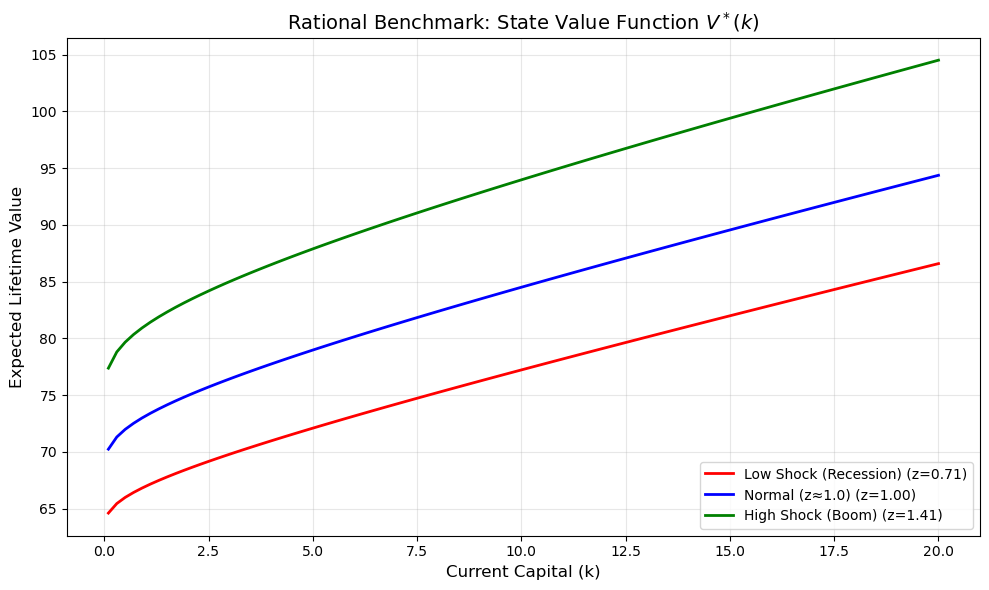

In [18]:
plt.figure(figsize=(10, 6))

k_grid = rational_agent.k_grid
z_grid = rational_agent.z_grid

# value function for the lowest, middle, and highest productivity shocks
z_indices_to_plot = [0, p.N_z // 2, p.N_z - 1]
colors = ['red', 'blue', 'green']
labels = ['Low Shock (Recession)', 'Normal (z≈1.0)', 'High Shock (Boom)']

for idx, color, label in zip(z_indices_to_plot, colors, labels):
    z_val = z_grid[idx]
    
    # Extract the exact state value function row for this specific z
    v_curve = rational_agent.v[idx, :]
    
    plt.plot(k_grid, v_curve, color=color, linewidth=2, label=f"{label} (z={z_val:.2f})")

plt.title("Rational Benchmark: State Value Function $V^*(k)$", fontsize=14)
plt.xlabel("Current Capital (k)", fontsize=12)
plt.ylabel("Expected Lifetime Value", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

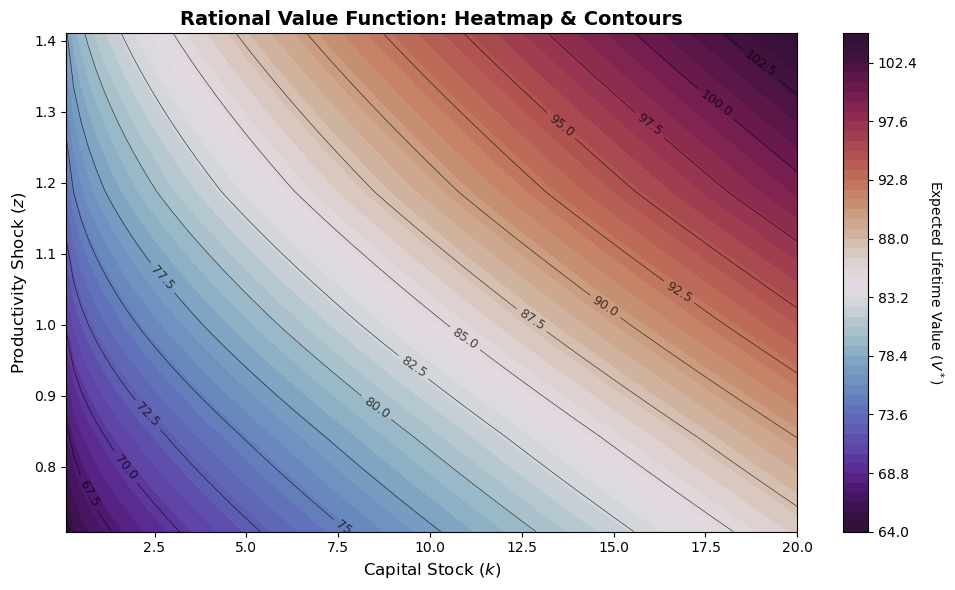

In [16]:
K, Z = np.meshgrid(rational_agent.k_grid, rational_agent.z_grid)
V = rational_agent.v

fig, ax = plt.subplots(figsize=(10, 6))
heatmap = ax.contourf(K, Z, V, levels=50, cmap='twilight_shifted') # contourf creates the filled color map
lines = ax.contour(K, Z, V, levels=15, colors='black', linewidths=0.5, alpha=0.7)
ax.clabel(lines, inline=True, fontsize=9, fmt='%1.1f')
cbar = fig.colorbar(heatmap, ax=ax)
cbar.set_label('Expected Lifetime Value ($V^*$)', rotation=270, labelpad=20)

ax.set_title("Rational Value Function: Heatmap & Contours", fontsize=14, fontweight='bold')
ax.set_xlabel("Capital Stock ($k$)", fontsize=12)
ax.set_ylabel("Productivity Shock ($z$)", fontsize=12)

plt.tight_layout()
plt.show()

#### Gaussian Processes

We now look at the GP prior the agent learning through experience and reasoning. The
"ReasoningandExperience" agent would have over this environment. To just view the
GP prior updates we can graph and compare them against the rational agents value
function.

In this simulation we have no actual "ExperienceandReasoning" agent yet. We just look
at how the GP prior evolves under the optimal actions. That is, a GP is initialized over
the state space. The rational agent is making the decisions, and the GP is updated based
on the observations. In this case the GP is a "note-taker" where the rational agent
is the sherpa leading the GP up mount everest.


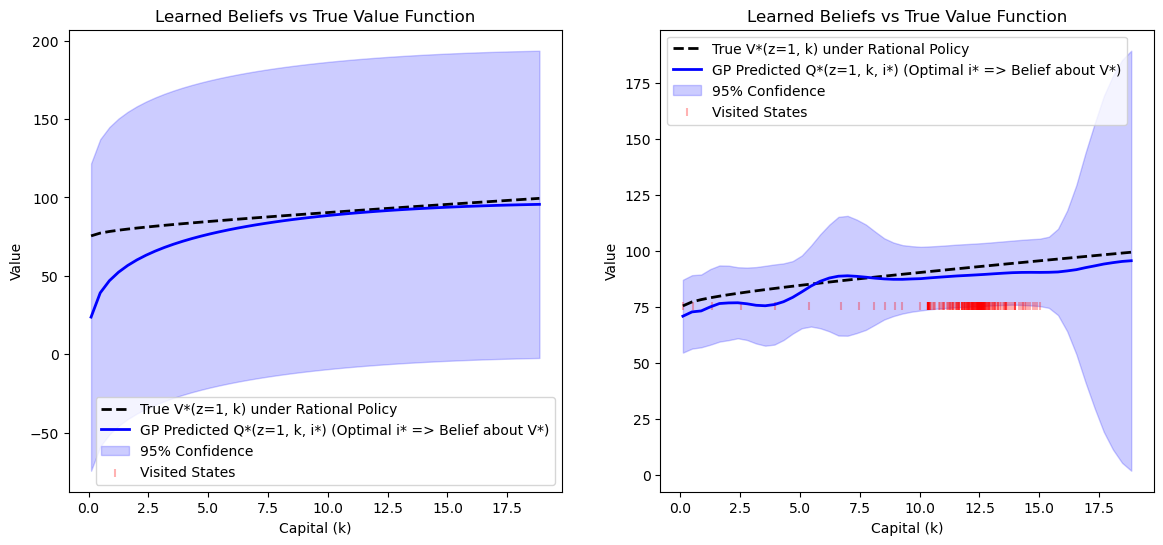

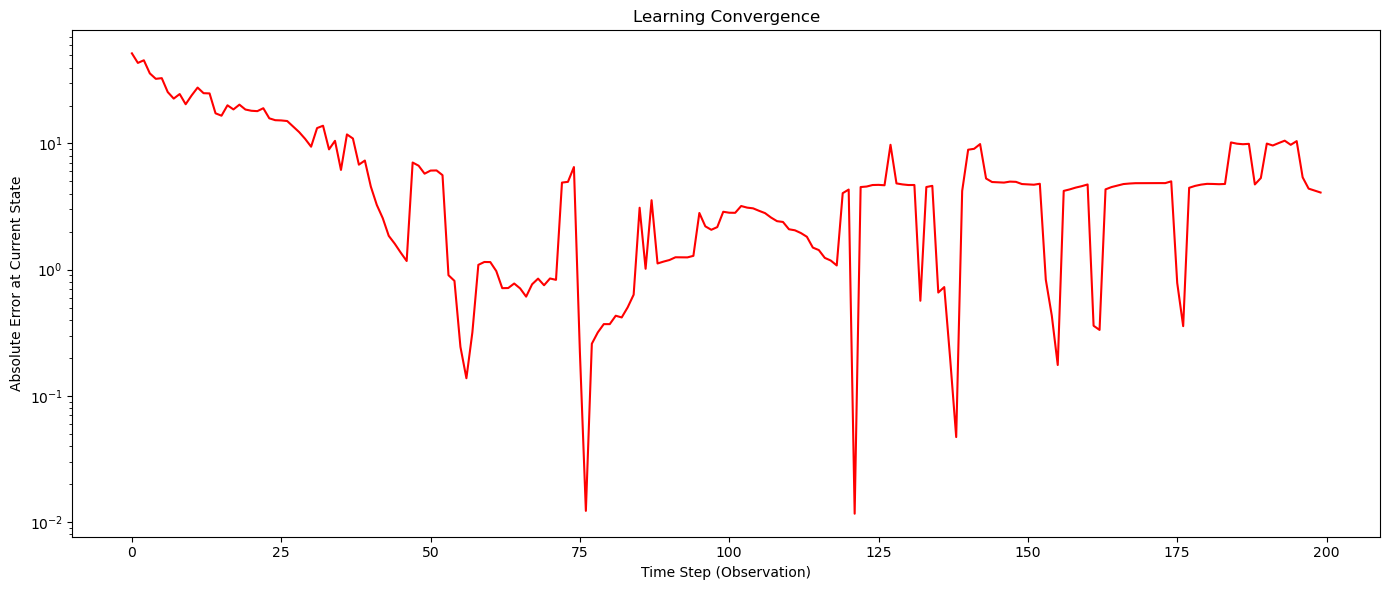

In [34]:
true_v_funcs = [
    interp1d(rational_agent.k_grid, rational_agent.v[i, :], kind="linear", fill_value="extrapolate")
    for i in range(rational_agent.actual_nz)
]

def get_true_v(z, k):
    z_idx = rational_agent._z_to_idx(z)
    return float(true_v_funcs[z_idx](k))

def simulate_gp_under_rational_policy(T=200, env=None, gp = None, initialization_state=(1.0, p.K_min), rational_agent=None):
    """Simulates the GP updates under rational policy for T periods, starting from the lowest capital level.
    Takes in investment environment, Gaussian Process Belief object.
    We also pass the rational agent to compute the optimal actions at each step.
    """
    z_t, k_t = initialization_state

    # Arrays to track convergence error over time
    errors = []

    for t in range(T):
        # Optimal current action
        kp_t = rational_agent.policy_kprime(z_t, k_t)
        i_t = kp_t - (1.0 - p.DELTA) * k_t
    
        # Transition
        d_t = env.get_reward(z_t, k_t, kp_t)
        z_next, k_next = env.transition(z_t, kp_t)
    
        # Optimal continuation action
        kp_next = rational_agent.policy_kprime(z_next, k_next)
        i_next = kp_next - (1.0 - p.DELTA) * k_next
    
        x_dec = np.array([z_t, k_t, i_t])
        x_out = np.array([z_next, k_next, i_next])
    
        # Track error before updating
        true_val = get_true_v(z_t, k_t)
        q_pred = gp.predict(x_dec)[0]
        errors.append(abs(true_val - q_pred))
    
        # Update GP
        gp.add_observation(x_dec, x_out, d_t)
    
        z_t, k_t = z_next, k_next

    return errors

def evaluate_gp_value_function(gp, rational_agent):
    """Plots the learned GP value function curve against the true rational benchmark at 
    z=1.0, across a range of capital levels."""
    test_k_grid = np.linspace(p.K_min, k_ss * 1.5, 50)
    true_v_curve = []
    gp_q_curve = []
    gp_std_curve = []

    for k in test_k_grid:
        true_v_curve.append(get_true_v(1.0, k))

        kp_test = rational_agent.policy_kprime(1.0, k) # optimal action at this test point
        i_test = kp_test - (1.0 - p.DELTA) * k
    
        # Query the GP
        x_query = np.array([1.0, k, i_test])
        q_pred, std_pred = gp.predict(x_query, return_std=True)
    
        gp_q_curve.append(q_pred[0])
        gp_std_curve.append(std_pred[0])
    
    true_v_curve = np.array(true_v_curve)
    gp_q_curve = np.array(gp_q_curve)
    gp_std_curve = np.array(gp_std_curve)

    return test_k_grid, true_v_curve, gp_q_curve, gp_std_curve

def plot_gp_value_function(ax, test_k_grid, true_v_curve, gp_q_curve, gp_std_curve, y_lim=None):
    """Plots the learned GP value function curve against the true rational benchmark at 
    z=1.0, across a range of capital levels."""
    # Plot the true value function and GP predictions with confidence intervals
    ax.plot(test_k_grid, true_v_curve, 'k--', linewidth=2, label="True V*(z=1, k) under Rational Policy")
    ax.plot(test_k_grid, gp_q_curve, 'b-', linewidth=2, label="GP Predicted Q*(z=1, k, i*) (Optimal i* => Belief about V*)")
    ax.fill_between(test_k_grid, 
                        gp_q_curve - 1.96 * gp_std_curve, 
                        gp_q_curve + 1.96 * gp_std_curve, 
                        color='b', alpha=0.2, label="95% Confidence")

    # Mark the region where the firm actually spent time exploring
    visited_k = gp.X_dec[:, 1]
    ax.scatter(visited_k, [np.min(true_v_curve)]*len(visited_k), color='red', marker='|', alpha=0.3, label="Visited States")

    if y_lim is not None:
        ax.set_ylim(y_lim)
    ax.set_xlabel("Capital (k)")
    ax.set_ylabel("Value")
    ax.set_title("Learned Beliefs vs True Value Function")
    ax.legend()

# Basic Test of the Simulation Function
gp_params = GPBeliefParameters(sigma0=50, lz=0.5, lk=2.0, li=1.0, sigma_n=2.0)
perpetuity_prior = PerpetuityPrior(p) # simple prior mean that assumes infinite perpetuity value based on current reward
gp = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=perpetuity_prior)

# before and after experiences
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # prior evaluation before any learning
plot_gp_value_function(axes[0], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve)

errors = simulate_gp_under_rational_policy(T=200, env=env, gp=gp, initialization_state=(1.0, p.K_min), rational_agent=rational_agent)
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # evaluation after learning
plot_gp_value_function(axes[1], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve)

def plot_convergence_error(ax, errors):
    # Plot 2: Convergence Error over Time
    ax.plot(range(T), errors, 'r-', linewidth=1.5)
    ax.set_xlabel("Time Step (Observation)")
    ax.set_ylabel("Absolute Error at Current State")
    ax.set_title("Learning Convergence")
    ax.set_yscale('log') # Log scale helps visualize exponential decay of error

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
plot_convergence_error(ax, errors)

plt.tight_layout()
plt.show()

#### Calibration and Sensitivities

Below I will show that the GP has some sensitivies to a couple of calibration elements.
The previous case was shown to demonstrate that a GP can converge around the true $V^*$.
The following experiments show some sensitivities.

1. *Prior Bias Sensitivity* The GP can have "prior drag". In this case if the prior initialization
is biased. The GP may never converge around the true $V^*$; however, it might match $V^*$ in shape.
In this case, the optimal policy will still match the rational agent. Which is interesting! To
definitively demonstrate that the "slope" / shape of the value function is matched we need to steepen
the value of capital. To do so we raise the interest rate parameter `R`. We can also initialize
the GP at 0, creating a huge downward bias. 

Note that even increasing the width of the prior belief to encompass the true value function.
Does not undo the bias. However, it might allow less bias.

Steady State Capital (k_ss): 12.562636606499492


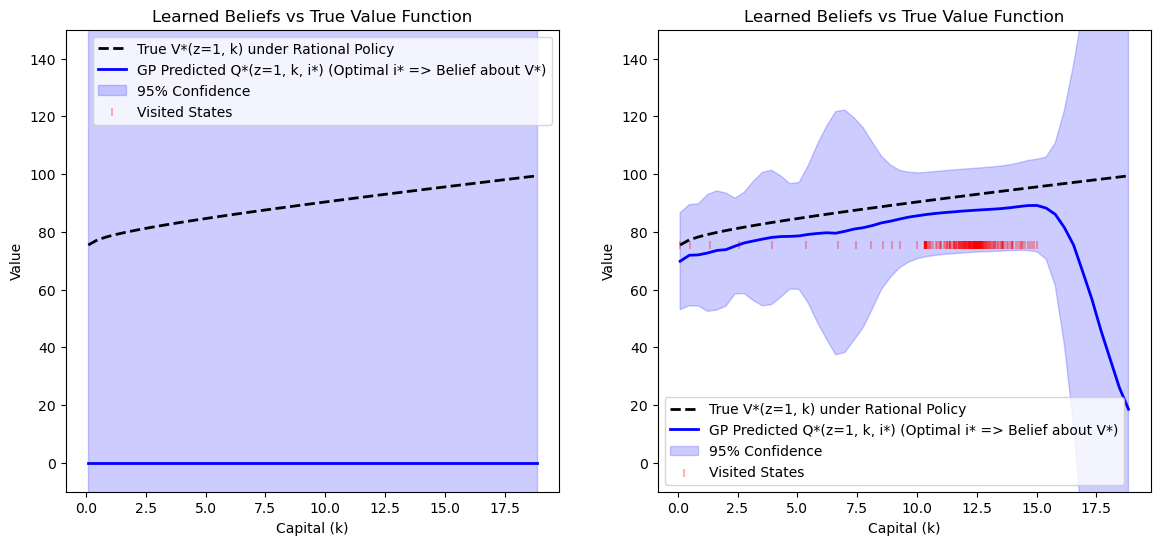

In [36]:
p = InvestmentParameters(KAPPA=0.5, SIGMA_EPS=0.05, DELTA=0.04, R=0.02, N_z=5) # parameters for environment
env = InvestmentEnvironment(p, seed=42) # the "world" the agent interacts with
rational_agent = RationalInvestmentAgent(p).fit() # rational benchmark agent
k_ss = rational_agent.fixed_point() # solves for the steady-state capital level

print("Steady State Capital (k_ss):", k_ss)
# Basic Test of the Simulation Function
gp_params = GPBeliefParameters(sigma0=100, lz=0.5, lk=2.0, li=1.0, sigma_n=2.0)
perpetuity_prior = ZeroPrior(p)
gp = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=ZeroPrior(p))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # prior evaluation before any learning
plot_gp_value_function(axes[0], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve, y_lim=(-10, 150))

errors = simulate_gp_under_rational_policy(T=200, env=env, gp=gp, initialization_state=(1.0, p.K_min), rational_agent=rational_agent)
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # evaluation after learning
plot_gp_value_function(axes[1], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve, y_lim=(-10, 150))


2. *Noise Calibration and Numerical Stability ($\sigma_n$ vs. $\sigma_\epsilon$)* In the formal mathematical specification of our firm, there is no measurement error: the agent perfectly observes its current capital $k_t$ and productivity $z_t$. However, the Gaussian Process requires an artificial observation noise parameter ($\sigma_n$) for two reasons: one statistical, and one computational.

Algorithmically, the GP updates its beliefs using the Temporal Difference (TD) target: $d_t + \beta \hat{Q}(s_{t+1}, a_{t+1})$. Because the future state $s_{t+1}$ is dictated by the random structural shock $z_{t+1}$ (governed by the environment's true productivity volatility $\sigma_\epsilon$), the realized target is inherently stochastic. It represents the true expected Bellman value *plus* a mean-zero realization error. 

The GP's ability to learn the true state-action value function is therefore highly sensitive to the calibration of $\sigma_n$ relative to $\sigma_\epsilon$:
* **Overfitting to Shocks (Low $\sigma_n$):** If the agent assumes observation noise is near zero but the actual environment is volatile (high $\sigma_\epsilon$), the GP treats every random productivity realization as a permanent structural shift. It forces the regression surface to pass exactly through every noisy TD target, resulting in a jagged, unstable value function that fails to capture the true mathematical expectation.
* **Underfitting the Signal (High $\sigma_n$):** Conversely, if the GP's noise parameter is set much higher than the actual environmental volatility, the agent dismisses genuine economic feedback as mere measurement error. The resulting value function becomes overly smoothed and flat, causing the agent to learn the option value of capital far too slowly. 

In the learning environment, an agent will frequently revisit the exact same, or highly similar, state-action pairs $(z, k, i)$ over time. In a standard noise-free Gaussian Process, having identical input points causes the kernel covariance matrix $K$ to become perfectly collinear and singular (a determinant of zero). When the algorithm attempts to invert this matrix to calculate the posterior ($K^{-1}$), the computation fails. 

To solve the *statistical* problem of noisy TD targets, the standard Bayesian updating formula requires adding the expected noise variance to the diagonal of the covariance matrix: $K + \sigma_n^2 I$. We are adding measurement error to the agent. So when the firm visits each state, a non-zero
$\sigma_n$ is intuitively saying that the firm does not perfectly observe its dividends. Doing this ensures invertibility.

Unfortunately, this operation is the exact mathematical definition of **Ridge Regression** (Tikhonov regularization). By simply attempting to model the macroeconomic uncertainty of tomorrow's shocks, the algorithm accidentally deploys this regularization. This ensures the matrix remains positive definite, well-conditioned, and numerically stable to invert, regardless of how aggressively the firm exploits a single capital state.

To achieve optimal convergence, $\sigma_n$ must be large enough to guarantee matrix invertibility, yet carefully calibrated to absorb the specific variance generated by $\sigma_\epsilon$, allowing the GP to smooth over individual shock realizations and converge on the true expectation operator required by the Bellman equation.

Steady State Capital (k_ss): 19.999993389470788


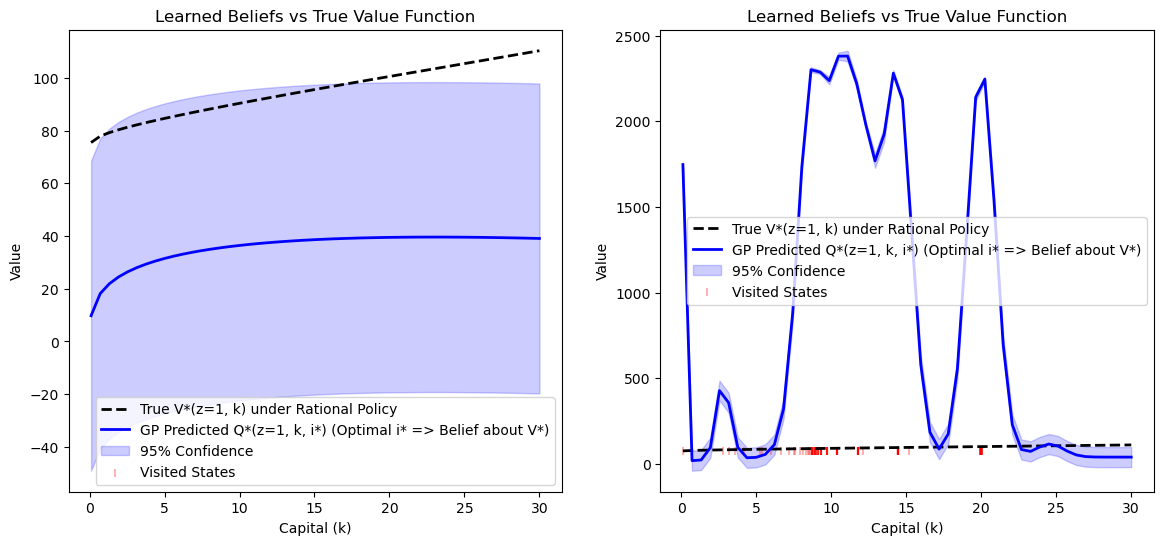

In [45]:
# CASE 1 - Overfitting to Shocks - Agent Wildly follows every shock.
p = InvestmentParameters(KAPPA=0.5, SIGMA_EPS=2, DELTA=0.04, R=0.05, N_z=5) # parameters for environment
env = InvestmentEnvironment(p, seed=42) # the "world" the agent interacts with
rational_agent = RationalInvestmentAgent(p).fit() # rational benchmark agent
k_ss = rational_agent.fixed_point() # solves for the steady-state capital level

print("Steady State Capital (k_ss):", k_ss)
# Basic Test of the Simulation Function
gp_params = GPBeliefParameters(sigma0=30, lz=0.5, lk=2.0, li=1.0, sigma_n=.5)
gp = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=PerpetuityPrior(p))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # prior evaluation before any learning
plot_gp_value_function(axes[0], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve)

errors = simulate_gp_under_rational_policy(T=200, env=env, gp=gp, initialization_state=(1.0, p.K_min), rational_agent=rational_agent)
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # evaluation after learning
plot_gp_value_function(axes[1], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve)

Steady State Capital (k_ss): 19.999993389470788


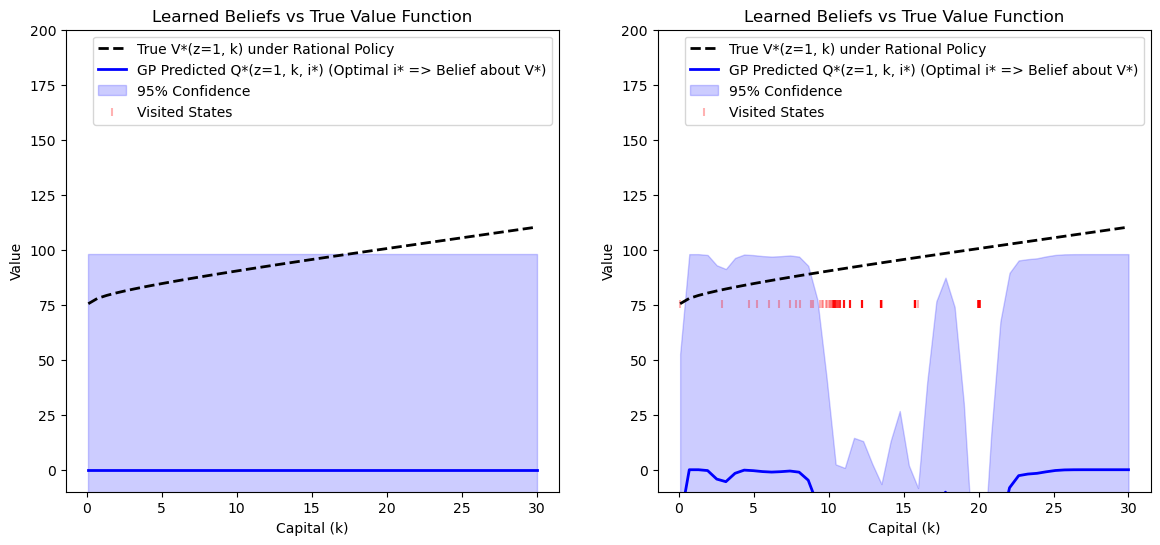

In [46]:
# CASE 2 - Oversmoothing - Agent ignores shocks and barely updates beliefs.
p = InvestmentParameters(KAPPA=0.5, SIGMA_EPS=2, DELTA=0.04, R=0.02, N_z=5) # parameters for environment
env = InvestmentEnvironment(p, seed=42) # the "world" the agent interacts with
rational_agent = RationalInvestmentAgent(p).fit() # rational benchmark agent
k_ss = rational_agent.fixed_point() # solves for the steady-state capital level

print("Steady State Capital (k_ss):", k_ss)
# Basic Test of the Simulation Function
gp_params = GPBeliefParameters(sigma0=50.0, lz=0.5, lk=2.0, li=1.0, sigma_n=50.0)
gp = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=ZeroPrior(p))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # prior evaluation before any learning
plot_gp_value_function(axes[0], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve, y_lim=(-10, 200))

errors = simulate_gp_under_rational_policy(T=200, env=env, gp=gp, initialization_state=(1.0, p.K_min), rational_agent=rational_agent)
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # evaluation after learning
plot_gp_value_function(axes[1], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve, y_lim=(-10, 200))

3. *Initialization Sensitivity* The GP can be sensitive to initialization if the firm gets stuck in certain
traps. This is desired behavior to some extent, however, this also means there is some initial condition
dependence. In this case because the GP follows the optimal policy if we initialize at the steady
state. The GP "note-taker" will never deviate from the steady state and therefore only learn the value
function in that area.

Notice on the plot below that the red markers do not deviate much from the steady state
capital stock.

Steady State Capital (k_ss): 6.73333928654571


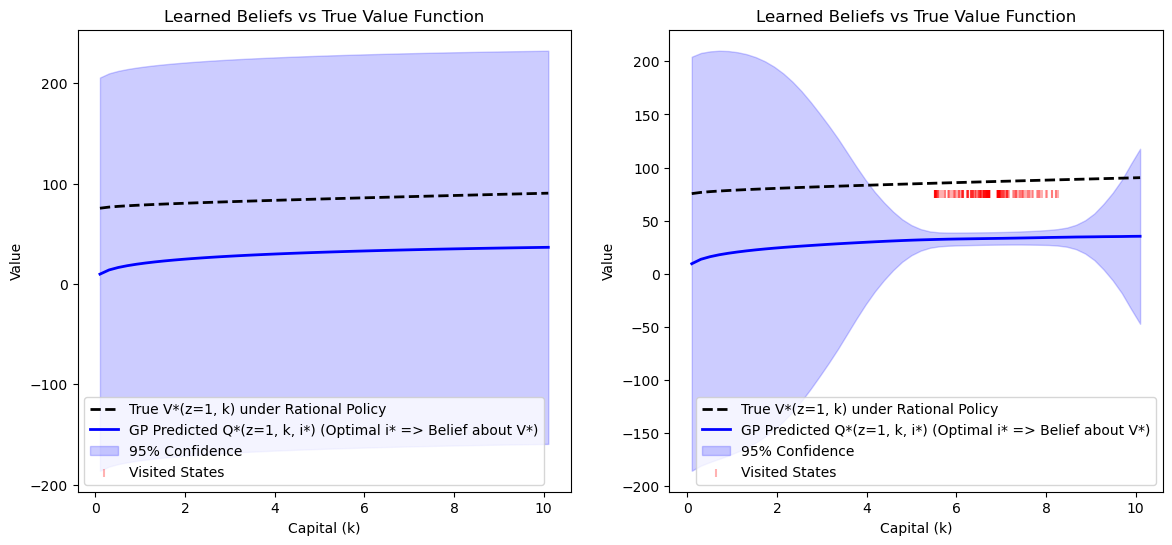

In [48]:
p = InvestmentParameters(KAPPA=0.5, SIGMA_EPS=0.05, DELTA=0.04, R=0.05, N_z=5) # parameters for environment
env = InvestmentEnvironment(p, seed=42) # the "world" the agent interacts with
rational_agent = RationalInvestmentAgent(p).fit() # rational benchmark agent
k_ss = rational_agent.fixed_point() # solves for the steady-state capital level

print("Steady State Capital (k_ss):", k_ss)
# Basic Test of the Simulation Function
gp_params = GPBeliefParameters(sigma0=100, lz=0.5, lk=2.0, li=1.0, sigma_n=2.0)
perpetuity_prior = PerpetuityPrior(p)
gp = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=perpetuity_prior)

# before and after experiences
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # prior evaluation before any learning
plot_gp_value_function(axes[0], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve)

# initialize at steady state
errors = simulate_gp_under_rational_policy(T=200, env=env, gp=gp, initialization_state=(1.0, k_ss), rational_agent=rational_agent)
test_k_grid, true_v_curve, gp_q_curve, gp_std_curve = evaluate_gp_value_function(gp, rational_agent) # evaluation after learning
plot_gp_value_function(axes[1], test_k_grid, true_v_curve, gp_q_curve, gp_std_curve)

#### Experience Based Agent

We can now run and view the experienced based agents decisions and updates in the
environment. The agent chooses policy regularized by the GP uncertainty.

1. Initializing Environment and Rational Benchmark...
2. Initializing GP Beliefs...
3. Initializing Experience Agent...

--- Starting 10-Step Experience Agent Simulation ---

Step 1: z = 1.000, k = 0.100
  Chosen Action: k' = 16.784 | Entropy Temp (δ_t) = 1000.0000

Step 2: z = 1.015, k = 16.784
  Chosen Action: k' = 15.980 | Entropy Temp (δ_t) = 0.2611

Step 3: z = 1.041, k = 15.980
  Chosen Action: k' = 15.377 | Entropy Temp (δ_t) = 0.4592

Step 4: z = 1.094, k = 15.377
  Chosen Action: k' = 14.774 | Entropy Temp (δ_t) = 0.7414

Step 5: z = 1.123, k = 14.774
  Chosen Action: k' = 14.171 | Entropy Temp (δ_t) = 0.2421

Step 6: z = 1.173, k = 14.171
  Chosen Action: k' = 13.568 | Entropy Temp (δ_t) = 0.2450

Step 7: z = 1.120, k = 13.568
  Chosen Action: k' = 12.965 | Entropy Temp (δ_t) = 0.3196

Step 8: z = 1.209, k = 12.965
  Chosen Action: k' = 12.362 | Entropy Temp (δ_t) = 0.2480

Step 9: z = 1.205, k = 12.362
  Chosen Action: k' = 11.960 | Entropy Temp (δ_t) = 0.1950

Step 10: z = 

/Users/adamcostarino/Repositories/independent_study_cosmin_ilut/scripts/../src/simulation/firm.py:448: UserWarning: Brentq failed to find a root for delta. Defaulting to uniform random policy.
  warnings.warn("Brentq failed to find a root for delta. Defaulting to uniform random policy.")


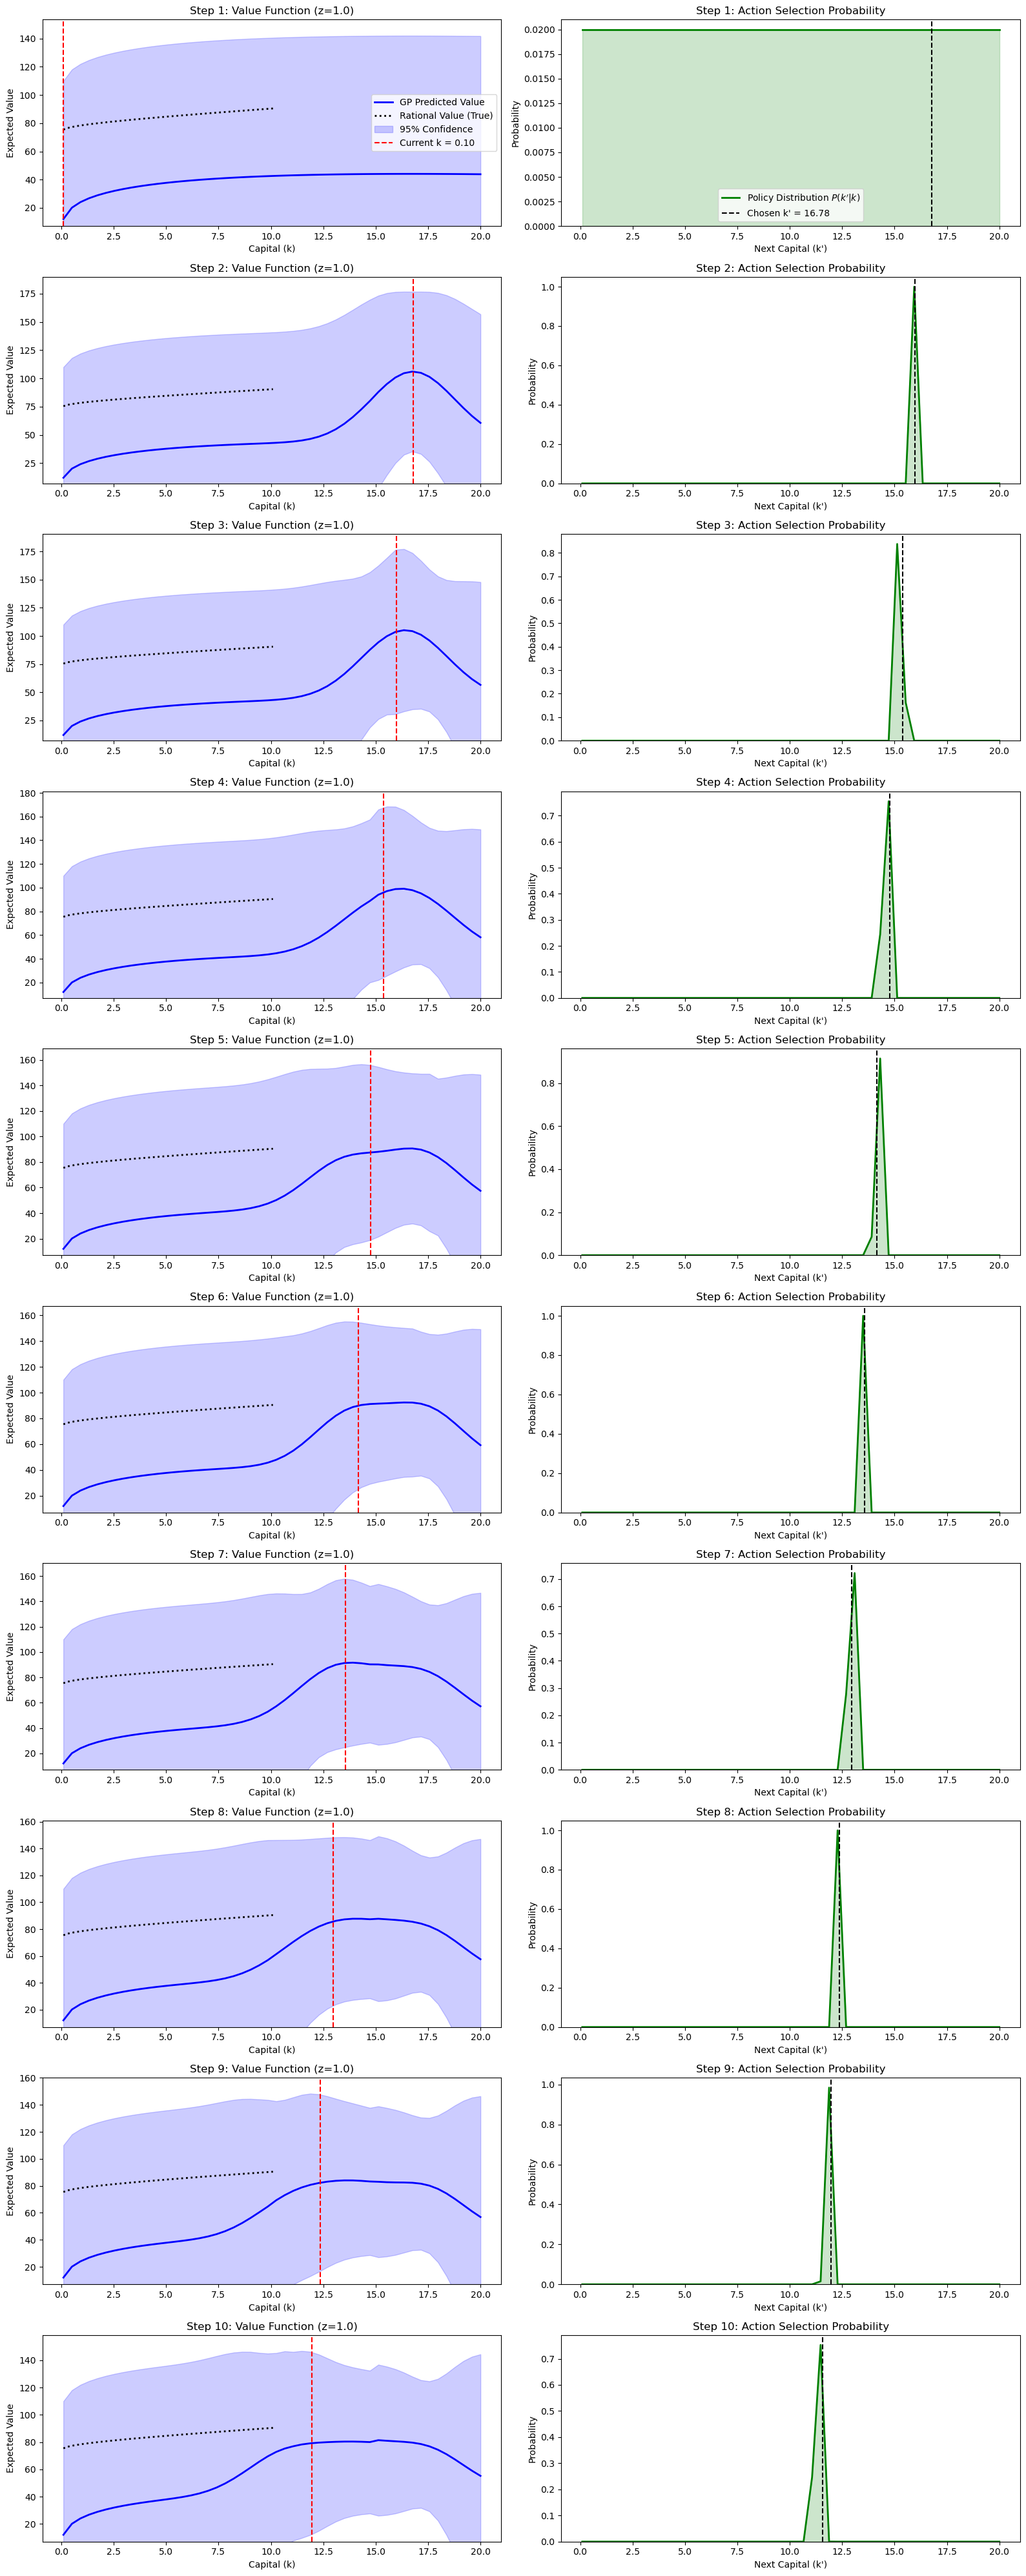

In [ ]:
p = InvestmentParameters(KAPPA=0.1, SIGMA_EPS=0.05, DELTA=0.05, R=0.04, N_z=5)
env = InvestmentEnvironment(p, seed=42)
rational_agent = RationalInvestmentAgent(p).fit()

gp_params = GPBeliefParameters(sigma0=50.0, lz=0.5, lk=2.0, li=1.0, sigma_n=0.5)
perpetuity_prior = PerpetuityPrior(p)
gp = GPBelief(env_params=p, gp_params=gp_params, prior_mean_fn=perpetuity_prior)

# Extract the true value curve once before the simulation starts
eval_k_grid, true_v_curve, _, _ = evaluate_gp_value_function(gp, rational_agent)

experience_agent_parameters = InvestmentAgentParameters(H=0.00005)
agent = ExperienceAgent(params=p, gp=gp, agent_params=experience_agent_parameters, seed=100)

test_k_grid = np.linspace(p.K_min, p.K_max, 50) 
test_kp_grid = np.linspace(p.K_min, p.K_max, 50) 

def snapshot_beliefs(current_agent):
    """Evaluates the GP's predicted value function across the full capital grid."""
    means, stds = [], []
    for k_val in test_k_grid:
        kp_g = current_agent.get_greedy_action(1.0, k_val)
        i_g = kp_g - (1.0 - p.DELTA) * k_val
        x_q = np.array([[1.0, k_val, i_g]]) 
        m, s = current_agent.gp.predict(x_q, return_std=True)
        means.append(m[0])
        stds.append(s[0])
    return np.array(means), np.array(stds)

def snapshot_policy(current_agent, z_val, k_val, temp):
    """Calculates the softmax policy distribution over possible k' choices."""
    i_grid = test_kp_grid - (1.0 - p.DELTA) * k_val
    
    # Evaluate GP for all possible investments from the current state
    x_q = np.column_stack((
        np.full_like(i_grid, z_val),
        np.full_like(i_grid, k_val),
        i_grid
    ))
    means, _ = current_agent.gp.predict(x_q, return_std=True)
    
    # Softmax calculation (with max subtraction for numerical stability)
    adjusted_means = (means - np.max(means)) / temp
    probs = np.exp(adjusted_means)
    probs /= np.sum(probs) # Normalize to create a valid probability distribution
    
    return probs

# Storage for plotting
belief_history = []
policy_history = []
step_data = []

# 4. Run the 10-Step Simulation
N_STEPS = 10
print(f"\n--- Starting {N_STEPS}-Step Experience Agent Simulation ---")
z_t, k_t = 1.0, p.K_min  

for t in range(N_STEPS):
    print(f"\nStep {t+1}: z = {z_t:.3f}, k = {k_t:.3f}")

    # Step 1: Action & Temperature
    kp_t, delta_t = agent.policy_kprime(z_t, k_t, return_delta=True)
    i_t = kp_t - (1.0 - p.DELTA) * k_t
    print(f"  Chosen Action: k' = {kp_t:.3f} | Entropy Temp (δ_t) = {delta_t:.4f}")

    # Snapshot beliefs and policy BEFORE the GP updates from this step's transition
    belief_history.append(snapshot_beliefs(agent))
    policy_history.append(snapshot_policy(agent, z_t, k_t, delta_t))
    step_data.append({'k_t': k_t, 'kp_t': kp_t})

    # Step 2: Transition
    d_t = env.get_reward(z_t, k_t, kp_t)
    z_next, k_next = env.transition(z_t, kp_t, custom_rng=agent.rng)

    # Step 3: Continuation
    kp_next = agent.get_greedy_action(z_next, k_next)
    i_next = kp_next - (1.0 - p.DELTA) * k_next

    # Step 4: GP Update
    x_dec = np.array([z_t, k_t, i_t])
    x_out = np.array([z_next, k_next, i_next])
    agent.gp.add_observation(x_dec, x_out, d_t)

    z_t, k_t = z_next, k_next

print("\nSimulation Complete. Generating plots...")

fig, axes = plt.subplots(N_STEPS, 2, figsize=(16, 4 * N_STEPS))

for t in range(N_STEPS):
    ax_val = axes[t, 0]
    ax_pol = axes[t, 1]
    
    mean, std = belief_history[t]
    probs = policy_history[t]
    current_k = step_data[t]['k_t']
    chosen_kp = step_data[t]['kp_t']
    
    # Left Column: GP Predicted Value Function
    # Plot GP using our full test_k_grid
    ax_val.plot(test_k_grid, mean, 'b-', linewidth=2, label="GP Predicted Value")
    
    # Plot Rational Value using the grid returned by the helper function
    ax_val.plot(eval_k_grid, true_v_curve, 'k:', linewidth=2, label="Rational Value (True)") 
    
    ax_val.fill_between(test_k_grid, mean - 1.96*std, mean + 1.96*std, color='b', alpha=0.2, label="95% Confidence")
    ax_val.axvline(current_k, color='red', linestyle='--', label=f"Current k = {current_k:.2f}")
    
    ax_val.set_title(f"Step {t+1}: Value Function (z={1.0:.1f})")
    ax_val.set_xlabel("Capital (k)")
    ax_val.set_ylabel("Expected Value")
    ax_val.set_ylim(bottom=min(mean)-5)
    if t == 0:
        ax_val.legend()

    # policy dist
    ax_pol.plot(test_kp_grid, probs, 'g-', linewidth=2, label="Policy Distribution $P(k'|k)$")
    ax_pol.fill_between(test_kp_grid, 0, probs, color='g', alpha=0.2)
    ax_pol.axvline(chosen_kp, color='black', linestyle='--', label=f"Chosen k' = {chosen_kp:.2f}")
    
    ax_pol.set_title(f"Step {t+1}: Action Selection Probability")
    ax_pol.set_xlabel("Next Capital (k')")
    ax_pol.set_ylabel("Probability")
    ax_pol.set_ylim(bottom=0)
    if t == 0:
        ax_pol.legend()

plt.tight_layout()
plt.show()